# Driver/Rider Simulation - Group Project 1

## Setup

#### Installing necessary packages

In [59]:
!pip install pandas
!pip install openpyxl
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [60]:
import pandas as pd
import importlib
import math
import numpy as np
import seaborn as sns
import copy
import ast
import matplotlib.pyplot as plt

#### Importing data and python files

In [61]:
df_drivers = pd.read_excel("drivers.xlsx")
df_riders = pd.read_excel("riders.xlsx")

In [62]:
import sim
import dat
import eval

Let's look at the data structure of each driver and rider data

In [63]:
df_drivers


,id,arrival_time,offline_time,initial_location,current_location,status,arrival_datetime,offline_datetime
0,1,5.011975,11.638223,"(0.7897740952818868, 8.194226996886005)","(13.492895938215721, 17.375090044074234)",offline,2025-12-01 13:00:43.110,2025-12-01 19:38:17.601
1,2,5.557763,11.732854,"(4.600342938200451, 13.82151625336585)","(13.6809497478333, 15.070060581064372)",offline-scheduled,2025-12-01 13:33:27.947,2025-12-01 19:43:58.273
2,3,5.661047,12.723458,"(9.09829206926925, 11.669336718393772)","(15.86922281798255, 9.936190354974855)",offline-scheduled,2025-12-01 13:39:39.768,2025-12-01 20:43:24.450
3,4,5.757413,12.793147,"(14.723720219958555, 14.743429470057318)","(14.232702333916698, 12.939560071816741)",offline-scheduled,2025-12-01 13:45:26.686,2025-12-01 20:47:35.330
4,5,5.769205,12.431118,"(13.023825947458846, 12.501871643860605)","(19.845683334071563, 7.3885004325174215)",offline-scheduled,2025-12-01 13:46:09.139,2025-12-01 20:25:52.025
...,...,...,...,...,...,...,...,...
4714,4715,999.227187,1006.755068,"(10.582800108224534, 11.812034114396816)","(13.25729373207955, 18.209269136491447)",busy,2026-01-11 23:13:37.872,2026-01-12 06:45:18.245
4715,4716,999.405774,1006.862390,"(12.406151105359658, 15.35675821295668)","(4.589410479873784, 18.529412880444497)",available,2026-01-11 23:24:20.786,2026-01-12 06:51:44.605
4716,4717,999.677163,1005.742867,"(12.021350723357354, 10.800778707086907)","(12.021350723357354, 10.800778707086907)",busy,2026-01-11 23:40:37.786,2026-01-12 05:44:34.323
4717,4718,999.875420,1007.105753,"(8.697026887552175, 9.716267540734085)","(8.697026887552175, 9.716267540734085)",busy,2026-01-11 23:52:31.514,2026-01-12 07:06:20.711


In [64]:
df_riders


,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime
0,1,5.048803,5.372603,5.668817,"(8.52776815255513, 11.374422951736026)","(11.22406718305943, 18.28586415472845)",dropped-off,2025-12-01 13:02:55.690,2025-12-01 13:22:21.370,2025-12-01 13:40:07.743
1,2,5.113495,5.344117,5.658663,"(4.7260253234018075, 13.921168220313202)","(11.219433016467919, 9.224932723238288)",dropped-off,2025-12-01 13:06:48.580,2025-12-01 13:20:38.822,2025-12-01 13:39:31.187
2,3,5.114319,5.819045,6.154474,"(9.34931432850313, 14.855954034601385)","(15.818906976292498, 14.556629597532137)",dropped-off,2025-12-01 13:06:51.547,2025-12-01 13:49:08.563,2025-12-01 14:09:16.107
3,4,5.210384,5.492225,5.915581,"(5.341657715440439, 9.121586876730834)","(11.832789025965816, 11.90864135355879)",dropped-off,2025-12-01 13:12:37.383,2025-12-01 13:29:32.010,2025-12-01 13:54:56.092
4,5,5.229512,5.421566,6.019653,"(5.444067188695589, 13.774420071355813)","(11.208517457838962, 5.792638826367501)",dropped-off,2025-12-01 13:13:46.244,2025-12-01 13:25:17.639,2025-12-01 14:01:10.751
...,...,...,...,...,...,...,...,...,...,...
34416,34417,999.896967,999.901101,1000.511766,"(17.383881680313788, 16.167189905352934)","(1.4455881474947407, 15.832155622577897)",dropoff-scheduled,2026-01-11 23:53:49.080,2026-01-11 23:54:03.964,2026-01-12 00:30:42.359
34417,34418,999.904409,999.992000,1000.311882,"(10.35936229509441, 15.976872698371508)","(12.371484599274163, 8.983058533069787)",dropoff-scheduled,2026-01-11 23:54:15.873,2026-01-11 23:59:31.201,2026-01-12 00:18:42.774
34418,34419,999.917332,1000.281098,-1.000000,"(1.423517208705026, 3.587920161165144)","(16.225226890700814, 15.365724565672975)",pickup-scheduled,2026-01-11 23:55:02.394,2026-01-12 00:16:51.953,NaT
34419,34420,999.928357,1000.026926,-1.000000,"(9.41383222891094, 11.541866755795697)","(15.160341486375795, 17.106591057724966)",pickup-scheduled,2026-01-11 23:55:42.087,2026-01-12 00:01:36.933,NaT


## Exploratory Data Analysis of Provided Data

#### Riders

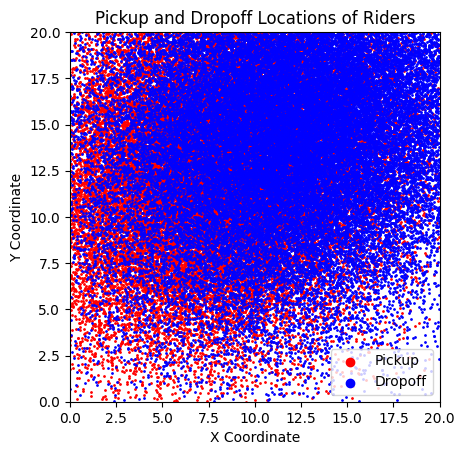

In [65]:
# plot of pickup locations and delivery locations, with pickups in blue and dropoffs in red 

rider_eda_df = df_riders.copy()

rider_eda_df["pickup_location"] = rider_eda_df["pickup_location"].apply(ast.literal_eval)
rider_eda_df["dropoff_location"] = rider_eda_df["dropoff_location"].apply(ast.literal_eval)

pickup_x = rider_eda_df["pickup_location"].apply(lambda p: p[0])
pickup_y = rider_eda_df["pickup_location"].apply(lambda p: p[1])

dropoff_x = rider_eda_df["dropoff_location"].apply(lambda p: p[0])
dropoff_y = rider_eda_df["dropoff_location"].apply(lambda p: p[1])

plt.figure()

plt.scatter(pickup_x, pickup_y, c="red", s=1, label="Pickup")
plt.scatter(dropoff_x, dropoff_y, c="blue", s=1, label="Dropoff")

plt.xlim(0, 20)
plt.ylim(0, 20)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Pickup and Dropoff Locations of Riders")
plt.legend(markerscale=6)

plt.show()



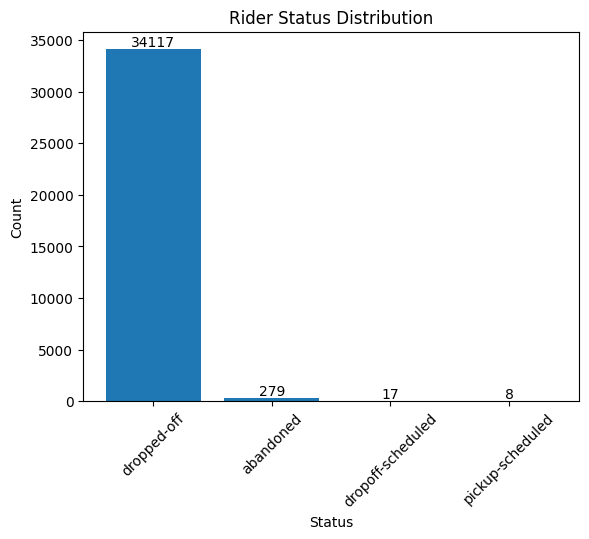

In [66]:
# bar plot of status at end of simulation


status_counts = df_riders["status"].value_counts()

plt.figure()
bars = plt.bar(status_counts.index, status_counts.values)

plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Rider Status Distribution")
plt.xticks(rotation=45)


# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

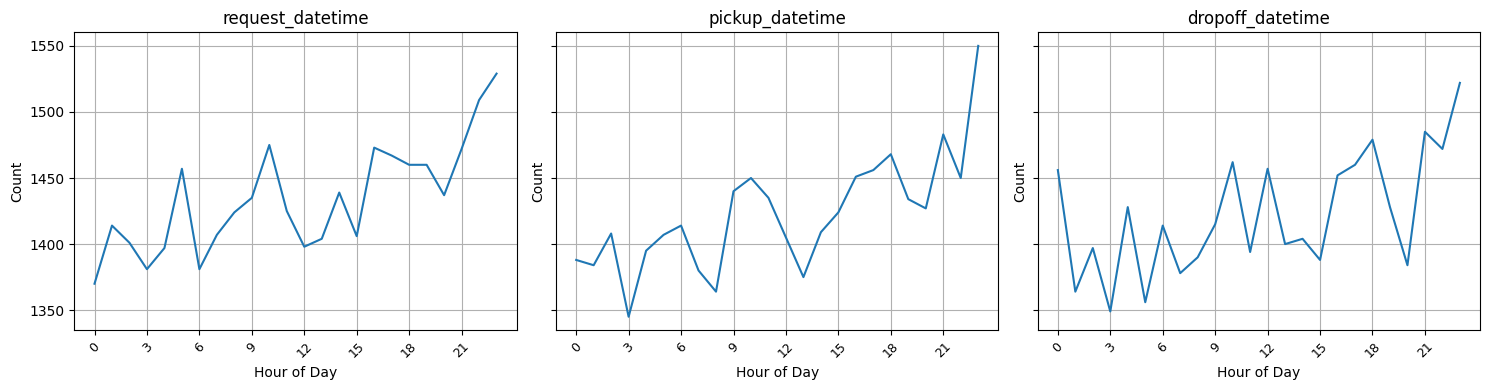

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

def time_plots(columns, df, tick_interval=3):
    date_df = df.copy()
    n_cols = len(columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 4), sharey=True)
    
    if n_cols == 1:
        axes = [axes]

    for ax, column in zip(axes, columns):
        date_df[column] = pd.to_datetime(date_df[column])
        date_df["hour_of_day"] = date_df[column].dt.hour
        hour_counts = date_df["hour_of_day"].value_counts().sort_index()
        
        ax.plot(hour_counts.index, hour_counts.values)
        
        xticks = list(range(0, 24, tick_interval))
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=45, fontsize=9)
        
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Count")
        ax.set_title(column)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

time_plots(["request_datetime", "pickup_datetime", "dropoff_datetime"], df_riders, tick_interval=3)


#### Drivers

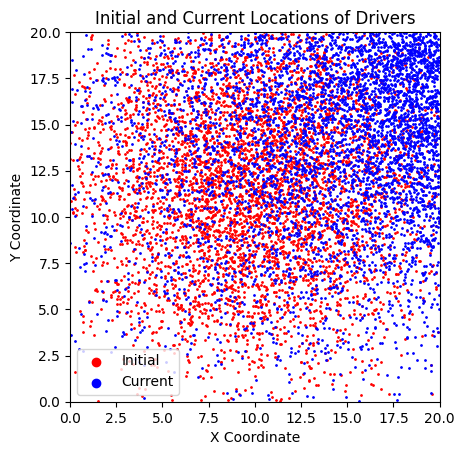

In [68]:

driver_eda_df = df_drivers.copy()

driver_eda_df["initial_location"] = driver_eda_df["initial_location"].apply(ast.literal_eval)
driver_eda_df["current_location"] = driver_eda_df["current_location"].apply(ast.literal_eval)

initial_x = driver_eda_df["initial_location"].apply(lambda p: p[0])
initial_y = driver_eda_df["initial_location"].apply(lambda p: p[1])

current_x = driver_eda_df["current_location"].apply(lambda p: p[0])
current_y = driver_eda_df["current_location"].apply(lambda p: p[1])

plt.figure()

plt.scatter(initial_x, initial_y, c="red", s=1, label="Initial")
plt.scatter(current_x, current_y, c="blue", s=1, label="Current")

plt.xlim(0, 20)
plt.ylim(0, 20)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Initial and Current Locations of Drivers")
plt.legend(markerscale=6)

plt.show()

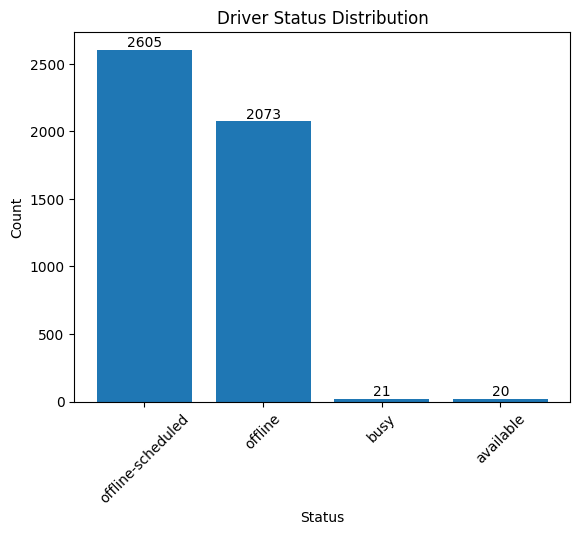

In [69]:
# bar plot of status at end of simulation

status_counts = df_drivers["status"].value_counts()

plt.figure()
bars = plt.bar(status_counts.index, status_counts.values)

plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Driver Status Distribution")
plt.xticks(rotation=45)


# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

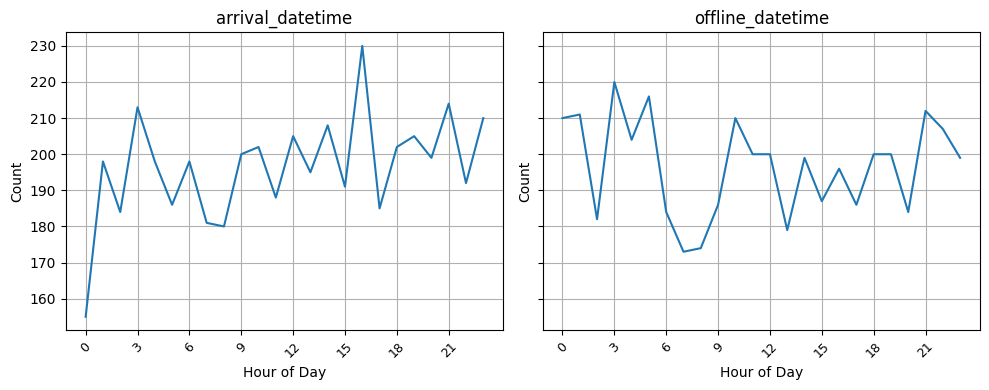

In [70]:
# plot driver time info

time_plots(["arrival_datetime", "offline_datetime"], df_drivers)


## BoxCar Simulation

#### Running the Simulation and bootstrapping KPI values

We run `simulate_boxcar(Termination)` function from `sim.py` python file. 

To account for randomness/variation in our simulation, we run 100 simulations for 1000 hours, recording the kpi values of each and storing them for further analysis.

In [71]:
importlib.reload(sim)
importlib.reload(eval)

# number of samples FOR ACTUAL REPORT, WE SHOULD RUN FOR LONGER, DO N=1000+
N = 100

# initialise empty lists for storage of kpi values
abandon_rates = np.zeros(N)
mean_avg_hourly_earnings = np.zeros(N)
mean_resting_times = np.zeros(N)
mean_waiting_times = np.zeros(N)

# initialise empty list for gini coefficients of hourly earnings (measure of fairness among drivers)
gini_avg_hourly_earnings = np.zeros(N)

for i in range(N):
    # run simulation for 1000 hours
    kpi = sim.simulate_boxcar(1000)
    
    # find abandon rate
    total_riders_sim = len(kpi["waiting_times"])
    abandon_rates[i] = kpi["abandon_count"] / kpi["total_number_riders"]

    # find mean and gini coefficient of avg hourly earnings
    mean_avg_hourly_earnings[i] = np.mean(kpi["avg_hourly_earnings"])
    gini_avg_hourly_earnings[i] = eval.gini(kpi["avg_hourly_earnings"])

    # find mean resting and waiting times
    mean_resting_times[i] = np.mean(kpi["total_resting_times"])
    mean_waiting_times[i] = np.mean(kpi["waiting_times"])

#### Evaluation of metrics

Now use these to find the means and 95% confidence interval of each performance metric. This allows us to intepret our results better.

In [72]:
# define all metrics in a list
all_metrics = [abandon_rates, mean_waiting_times, mean_resting_times, mean_avg_hourly_earnings, gini_avg_hourly_earnings]
all_metric_names = ["Abandon Rates", "Mean Waiting Times", "Mean Resting Times", "Mean Hourly Earnings", "Gini Hourly Earnings"]

# find means, confidence intervals of the estimates, and 95% prediction interval for each kpi
means = []
CI_95 = []
PI_95 = []

# for each metric
for i in range(len(all_metrics)):
    # i-th list of values in all_metrics
    vals = all_metrics[i]
    # find means (and gini coefficient estimate)
    mean_i = np.mean(vals)
    means.append(float(mean_i))
    # find confidence intervals of estimate
    std_i = float(np.std(vals, ddof=1)) 
    # append confidence interval of estimate and prediction interval
    CI_95.append(
        [float(mean_i - (1.96/np.sqrt(N))* std_i), float(mean_i + (1.96/np.sqrt(N))* std_i)]
    )
    PI_95.append(
        [float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))]
    )
    if all_metric_names[i] == "Gini Hourly Earnings":
        print(f"{all_metric_names[i]}"
              f"\nGini Coefficient: {np.round(mean_i, 5)}"
              f"\n95% Confidence Interval on Gini Coefficient Estimate: {np.round(CI_95[-1], 5)}"
              f"\n95% Prediction Interval: {np.round(PI_95[-1], 5)}"
              f"\n=====================================================================================")
    else:
        print(f"{all_metric_names[i]}"
              f"\nMean: {np.round(mean_i, 5)}" 
              f"\n95% Confidence Interval on Mean Estimator: {np.round(CI_95[-1], 5)}" 
              f"\n95% Prediction Interval: {np.round(PI_95[-1], 5)}"
              f"\n=====================================================================================")

Abandon Rates
Mean: 0.26598
95% Confidence Interval on Mean Estimator: [0.26335 0.26861]
95% Prediction Interval: [0.24133 0.29469]
Mean Waiting Times
Mean: 0.41397
95% Confidence Interval on Mean Estimator: [0.41304 0.4149 ]
95% Prediction Interval: [0.40573 0.42341]
Mean Resting Times
Mean: 0.4028
95% Confidence Interval on Mean Estimator: [0.3951  0.41049]
95% Prediction Interval: [0.3335  0.47506]
Mean Hourly Earnings
Mean: 21.26409
95% Confidence Interval on Mean Estimator: [21.24563 21.28254]
95% Prediction Interval: [21.05739 21.4214 ]
Gini Hourly Earnings
Gini Coefficient: 0.07517
95% Confidence Interval on Gini Coefficient Estimate: [0.0749  0.07544]
95% Prediction Interval: [0.07296 0.07811]


We can also evaluate our model using density plots of the means of our kpi values.

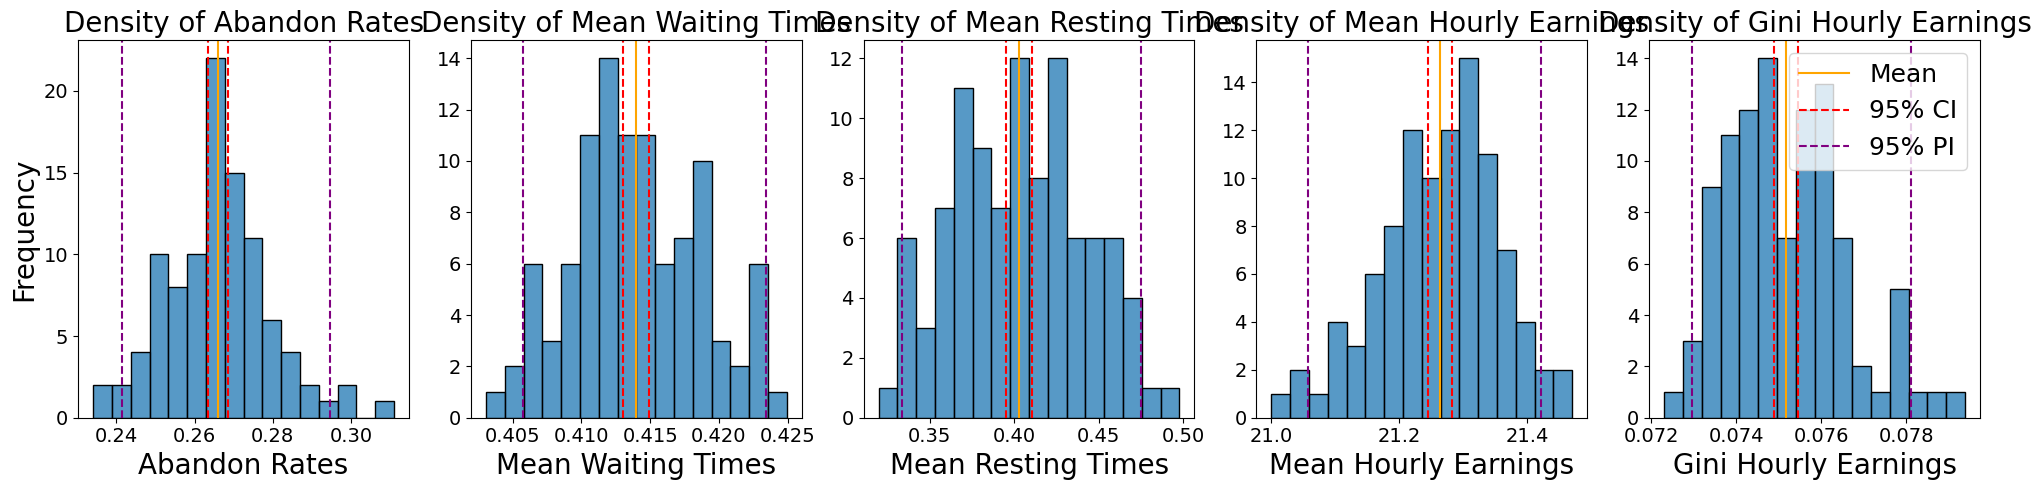

In [73]:
importlib.reload(eval)
# plot histograms of all metrics
eval.hist_plot(all_metrics, all_metric_names, means, CI_95, PI_95)

We should now look towards comparing our results with the data given to see how similar our results are.
We should then look into improvements we can make into our model to not only get it to match the data more, but also suggest improvements we could make to the model to provide a better service to both our drivers and riders based on the kpi values

#### Real Data KPI values

In [74]:
importlib.reload(dat)
# find real kpi values
real_kpis = dat.real_kpi_vals(df_drivers, df_riders)

# define as a list for future use
real_abandon_rates = float(real_kpis["abandon_rates"])
mean_real_wait_times = float(np.mean(real_kpis["wait_times"]))
real_kpi_vals = [real_abandon_rates, mean_real_wait_times]

Let's compare these KPI values from the real dataset to our bootstrapped simulations

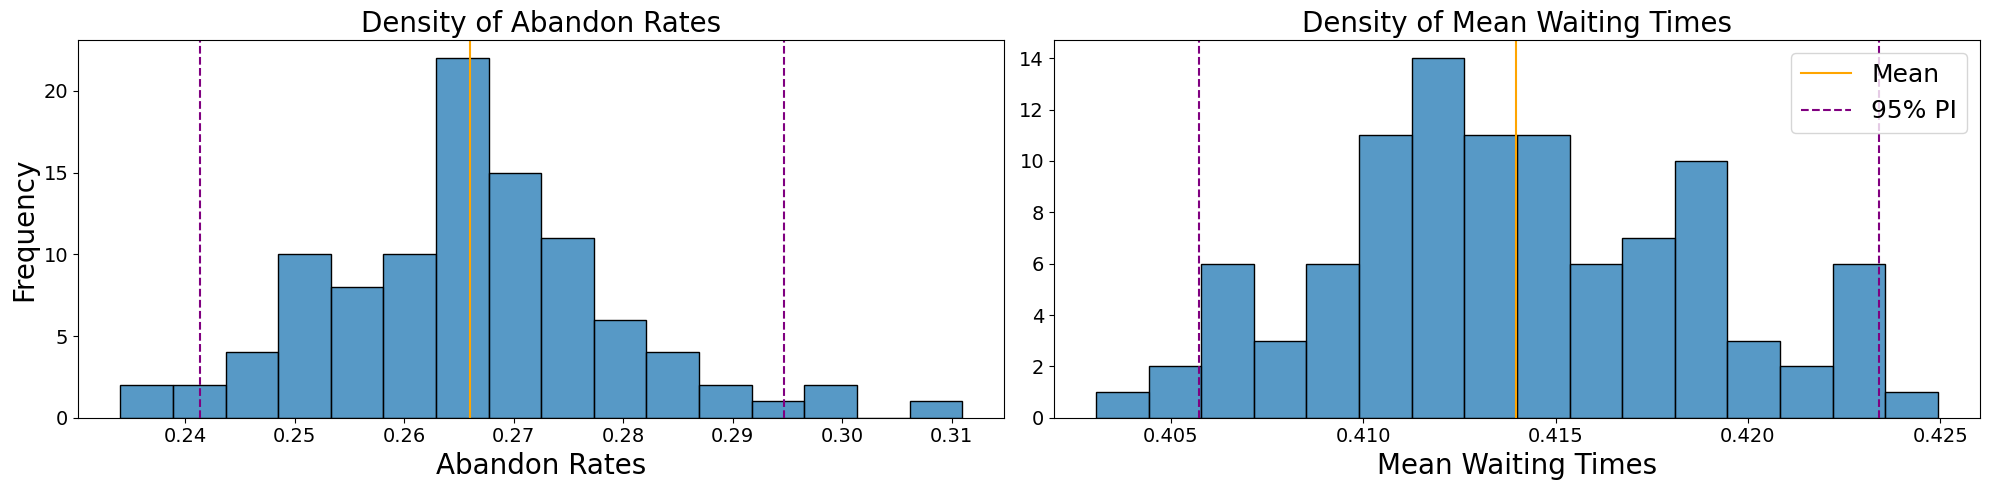

In [75]:
importlib.reload(eval)

# take the metrics we can compare to the real kpi values (abandon rates and mean waiting times)
kpi_sim_comp = all_metrics[:2]
kpi_sim_comp_names = all_metric_names[:2]
kpi_sim_comp_means = means[:2]
kpi_PIs = PI_95[:2]

eval.hist_plot(kpi_sim_comp, kpi_sim_comp_names, means=kpi_sim_comp_means, PIs=kpi_PIs)

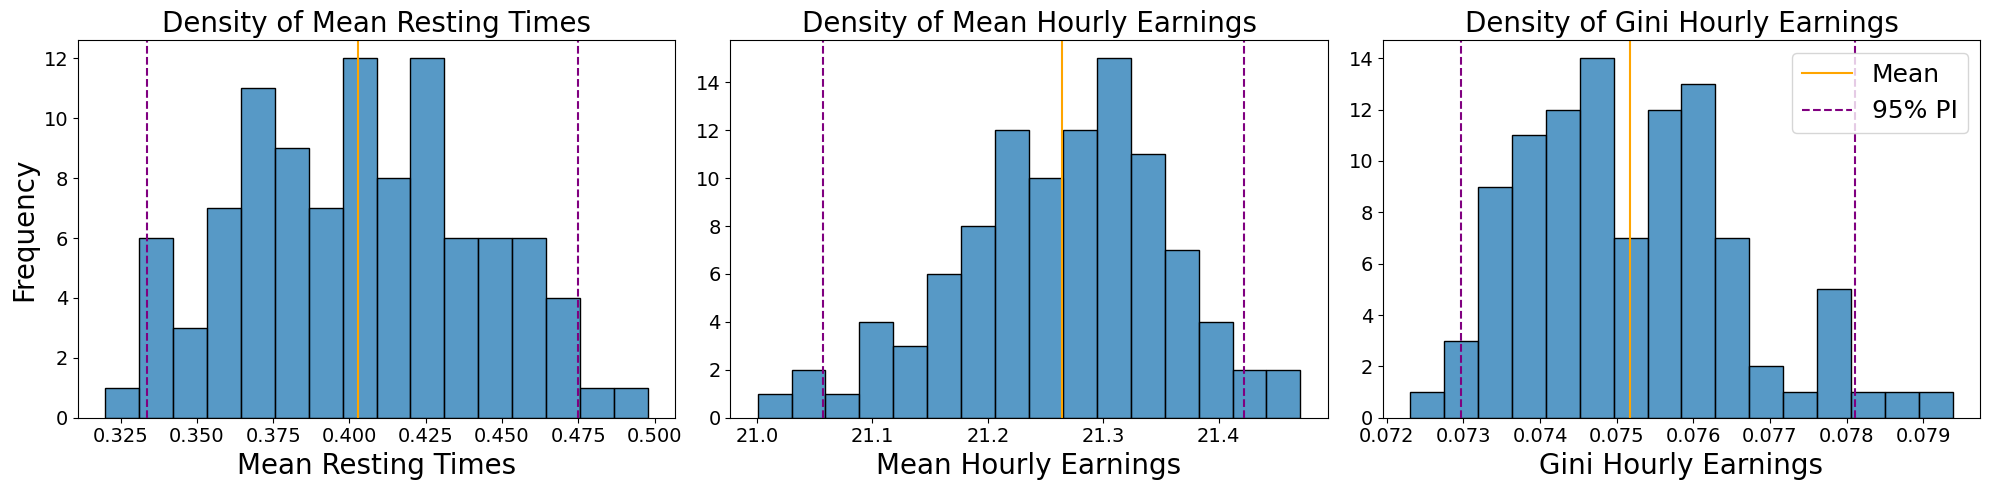

In [76]:
importlib.reload(eval)

# take the metrics we can compare to the real kpi values (abandon rates and mean waiting times)
kpi_sim_comp = all_metrics[2:5]
kpi_sim_comp_names = all_metric_names[2:5]
kpi_sim_comp_means = means[2:5]
kpi_PIs = PI_95[2:5]

eval.hist_plot(kpi_sim_comp, kpi_sim_comp_names, means=kpi_sim_comp_means, PIs=kpi_PIs)

As we can see, our simulation is not similar to the real data given to us by BoxCar.